# Tarea 0 --- IELE756
**Team members**: [Felipe Alonso, Juan costa]
**Region**: [ 10]
**Date**: [ 13/03/2026]


## Parte 0: Configuración del entorno

Primero verificamos que el entorno está funcionando correctamente importando `pandas` y comprobando su versión. Esta librería será la herramienta principal para cargar, filtrar y analizar los datos a lo largo de todo el curso.

In [ ]:
import pandas as pd
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.1.4


---
## Parte 1: Censo 2024

El Censo 2024 provee datos demográficos a nivel de persona para todo Chile. Los datos están almacenados en formato **Parquet**, un formato columnar que permite cargar solo las columnas necesarias, lo que reduce significativamente el uso de memoria en tablas de millones de filas.

### 1.1 Carga de datos

Cargamos la tabla `personas_censo2024.parquet` seleccionando únicamente las columnas relevantes para el análisis: región, comuna, sexo, edad, nacionalidad, escolaridad y situación laboral. Esto es importante porque la tabla completa tiene ~19 millones de filas.

In [ ]:
import pandas as pd
persona = pd.read_parquet(
"personas_censo2024.parquet",
columns=["region", "comuna", "sexo", "edad",
"p27_nacionalidad", "p27_nacionalidad_rec",
"escolaridad", "sit_fuerza_trabajo"],
)

### 1.2 Inspección de la tabla nacional

Antes de filtrar, inspeccionamos la tabla completa para entender su estructura: cuántas filas y columnas tiene, qué tipos de datos contiene cada columna, y si hay valores nulos. Esto nos ayuda a detectar problemas de calidad de datos desde el inicio.

In [ ]:
persona.shape

(18480432, 8)

In [ ]:
persona.dtypes

region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

In [ ]:
persona.head(10)

,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


In [ ]:
persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


### 1.3 Filtro a la Región de Los Lagos (Región 10)

Filtramos la tabla nacional para quedarnos solo con las personas de nuestra región asignada: la **Región de Los Lagos** (código numérico `10`). Es importante notar que en el Censo la columna `region` es de tipo entero, no texto.

In [ ]:
my_region = persona[persona["region"] == 10]
print(f"Rows in my region: {len(my_region):,}")

Rows in my region: 890,284


### 1.4 Distribución de nacionalidad

Analizamos la distribución de la variable `p27_nacionalidad_rec` (nacionalidad recodificada) en nuestra región. Esta variable clasifica a las personas como chilenas o extranjeras. Calculamos además el **porcentaje de residentes nacidos en el extranjero** en la Región de Los Lagos.

In [ ]:
foreign = my_region["p27_nacionalidad_rec"] \
.value_counts(normalize=True)
print(f"% foreign-born: {foreign.get(2, 0):.1%}")

% foreign-born: 3.4%


---
## Parte 2: ENO — Enfermedades de Notificación Obligatoria

El dataset ENO contiene los reportes de enfermedades de notificación obligatoria desde 2007 hasta 2024. Está almacenado como un archivo **CSV delimitado por punto y coma** (`;`) con codificación `utf-8-sig`. A diferencia del Censo, la columna `region` aquí es texto (ej: `"Región de Los Lagos"`).

### 2.1 Carga del dataset ENO

Cargamos el archivo CSV especificando el separador correcto (`;`) y la codificación `utf-8-sig`. Imprimimos el total de filas y los nombres de las columnas para tener una primera visión del dataset.

In [ ]:
eno = pd.read_csv(
"20241218_base_eno_final.csv",
sep=";", encoding="utf-8-sig", low_memory=False)
print(f"Total rows: {len(eno):,}")
print(eno.columns.tolist())

/var/folders/l2/mjb7zmgd2rjcpbv8bw1glql80000gn/T/ipykernel_1346/3650351141.py:1: DtypeWarning: Columns (6,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv(


Total rows: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


### 2.2 Filtro a la Región de Los Lagos

Filtramos el dataset usando el nombre de la región tal como aparece en el campo `region`. A diferencia del Censo, aquí el identificador de región es texto, por lo que hay que coincidir exactamente con el string correspondiente.

In [ ]:
eno_region = eno[eno["region"] == "Región de Los Lagos"]
print(f"Rows in my region: {len(eno_region):,}")

Rows in my region: 17,829


### 2.3 Notificaciones por año

Contamos el número de notificaciones por año usando la columna `anho_notificacion`. Ordenamos por año (`sort_index()`) para visualizar la evolución temporal como un gráfico de barras verticales. Esto permite identificar tendencias, peaks epidémicos o cambios en la vigilancia a lo largo del tiempo, ademas para los siguentes graficos usamos .plot(kind="bar") para visualizarlos.

In [ ]:
eno_region["anho_notificacion"].value_counts().sort_index()

<Axes: xlabel='anho_notificacion'>

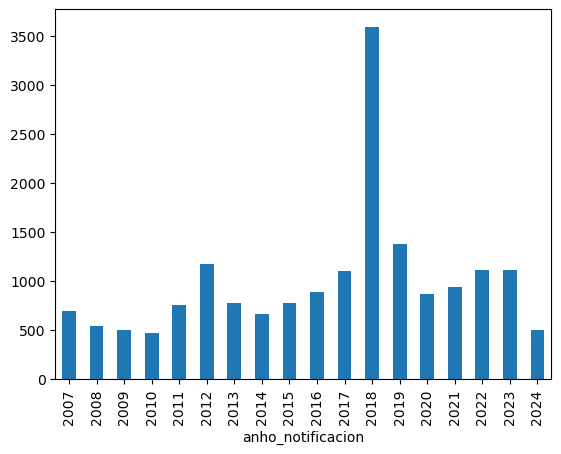

In [ ]:
eno_region["anho_notificacion"].value_counts().sort_index().plot(kind="bar")

### 2.4 Top 5 enfermedades más notificadas

Identificamos las 5 enfermedades con mayor número de notificaciones en nuestra región usando `value_counts()` sobre la columna `ENO`. El resultado se presenta como un **gráfico de barras horizontal** (`barh`) para facilitar la lectura de los nombres de las enfermedades.

In [ ]:
eno_region["ENO"].value_counts().head(5)

<Axes: ylabel='ENO'>

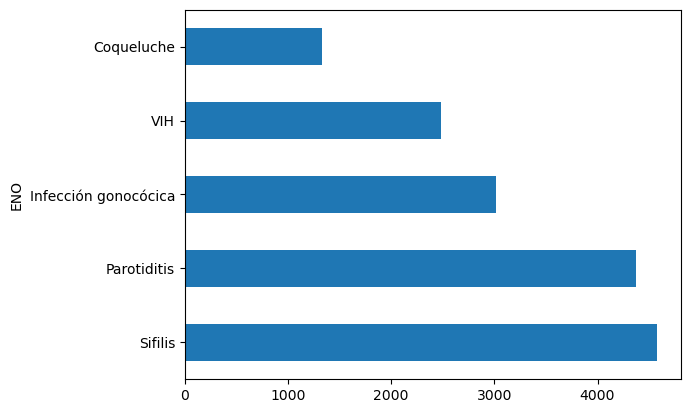

In [ ]:
eno_region["ENO"].value_counts().head(5).plot(kind="barh")

### 2.5 Distribución de nacionalidad en ENO

Analizamos la distribución de la variable `nacionalidad` en los registros ENO de nuestra región. Es esperable encontrar una categoría `"Desconocido"` — la reportamos sin eliminarla, ya que su presencia es informativa sobre la calidad del dato en el sistema de vigilancia epidemiológica.

In [ ]:
eno_region["nacionalidad"].value_counts(dropna=False)

Distribución de nacionalidad en mi región:
p27_nacionalidad
Chilena                                822563
Otra nacionalidad                       29595
No sabe / No responde                   26589
Doble nacionalidad (chilena y otra)      7442
No aplica / Missing                      4095
Name: count, dtype: int64


---
## Parte 3: GRD — Egresos Hospitalarios

El dataset GRD (Grupos Relacionados por el Diagnóstico) registra los egresos hospitalarios de establecimientos públicos. Los archivos están comprimidos en formato **ZIP**, con datos delimitados por **pipe** (`|`), uno por año. Cada archivo tiene 129 columnas, por lo que es fundamental usar `usecols` para cargar solo las columnas necesarias.

### 3.1 Carga del año 2024

Abrimos el archivo ZIP del año 2024 y cargamos el archivo de texto interno usando `pd.read_csv` con separador `|`. Seleccionamos solo 8 columnas relevantes: comuna, nacionalidad, sexo, diagnóstico principal, fechas de ingreso y alta, y campos de severidad GRD.

In [ ]:
import zipfile

cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
        "FECHA_INGRESO", "FECHAALTA",
        "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]

with zipfile.ZipFile("GRD_PUBLICO_2024.zip") as z:
    with z.open("GRD_PUBLICO_2024.txt") as f:
        grd = pd.read_csv(f, sep="|", usecols=cols, low_memory=False, encoding='latin-1')


print(f"Total discharges: {len(grd):,}")

Total discharges: 1,085,813


### 3.2 Filtro a la Región de Los Lagos

El dataset GRD **no tiene columna de región**. En su lugar, la columna `COMUNA` contiene el nombre de la comuna en mayúsculas. Para filtrar a nuestra región, definimos manualmente la lista de comunas que pertenecen a la Región de Los Lagos (provincias de Llanquihue, Chiloé, Osorno y Palena) y filtramos usando `.isin()`.

In [ ]:
my_comunas = [
    "PUERTO MONTT", "CALBUCO", "COCHAMO", "FRESIA", "FRUTILLAR",
    "LOS MUERMOS", "LLANQUIHUE", "MAULLIN", "PUERTO VARAS", # Prov. Llanquihue
    "CASTRO", "ANCUD", "CHONCHI", "CURACO DE VELEZ", "DALCAHUE",
    "PUQUELDON", "QUEILEN", "QUELLON", "QUEMCHI", "QUINCHAO", # Prov. Chiloé
    "OSORNO", "PUERTO OCTAY", "PURRANQUE", "PUYEHUE", "RIO NEGRO",
    "SAN JUAN DE LA COSTA", "SAN PABLO", # Prov. Osorno
    "CHAITEN", "FUTALEUFU", "HUALAIHUE", "PALENA" # Prov. Palena
]

grd_region = grd[grd["COMUNA"].isin(my_comunas)]

print(f"Discharges in Los Lagos region: {len(grd_region):,}")

print("\nComunas encontradas en los datos:")
print(grd_region["COMUNA"].unique())

Discharges in Los Lagos region: 54,614

Comunas encontradas en los datos:
['SAN JUAN DE LA COSTA' 'LOS MUERMOS' 'PUERTO MONTT' 'OSORNO'
 'PUERTO OCTAY' 'PUERTO VARAS' 'LLANQUIHUE' 'PURRANQUE' 'CASTRO'
 'FRUTILLAR' 'DALCAHUE' 'FRESIA' 'SAN PABLO' 'CALBUCO' 'QUINCHAO'
 'CHONCHI' 'ANCUD' 'QUEMCHI' 'PUYEHUE' 'PALENA']


### 3.3 Join con tabla CIE-10

La columna `DIAGNOSTICO1` contiene códigos CIE-10 (ej: `J18.9`) que no son directamente legibles. Para obtener descripciones en español, hacemos un **merge** con la tabla de referencia CIE-10 por el campo `Código`. Usamos `how="left"` para conservar todos los egresos, incluso aquellos sin código coincidente.

In [ ]:

cie10 = pd.read_excel("CIE-10.xlsx",
                      sheet_name="CIE 10")

grd_region = grd_region.merge(
    cie10[["Código", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1", right_on="Código",
    how="left")

### 3.4 Top 5 diagnósticos más frecuentes

Mostramos los 5 diagnósticos más comunes en los egresos hospitalarios de la Región de Los Lagos, usando la descripción legible obtenida del join con CIE-10. El resultado se presenta como un **gráfico de barras horizontal** para facilitar la lectura de las descripciones.

In [ ]:
grd_region["Descripción"].value_counts().head(5)

<Axes: ylabel='Descripción'>

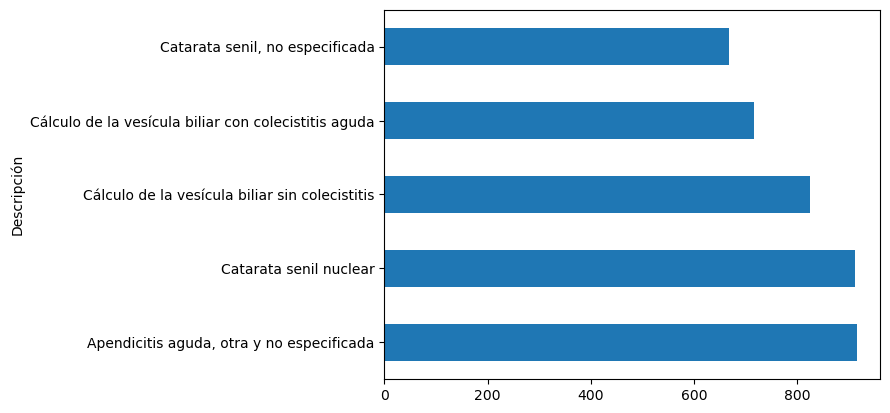

In [ ]:
grd_region["Descripción"].value_counts().head(5).plot(kind="barh")